In [20]:
%reset -f -s


import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from PIL import Image, ImageDraw, ImageFont
from pycocotools.coco import COCO
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from utils.takehome import DWDataset, CLASS_NAMES, display_images


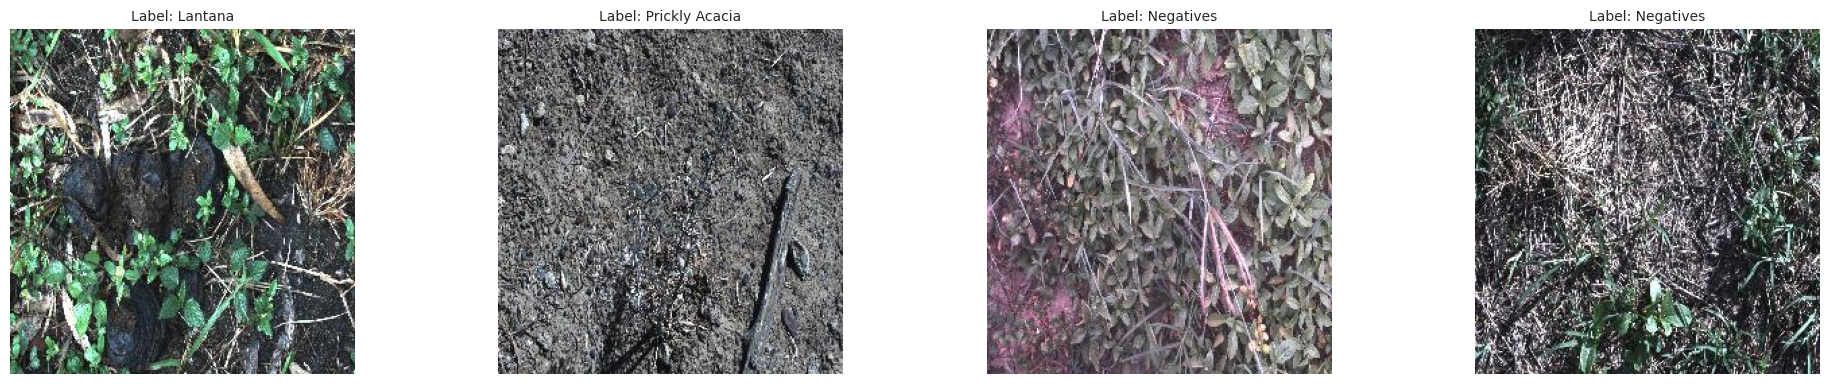

In [21]:
dataset = DWDataset("deepweeds", "test_subset0")
display_images(dataset, num_images=4)

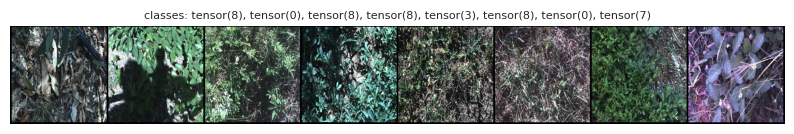

In [22]:
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
from matplotlib import pyplot as plt

def imshow(inp, title=None):
    plt.figure(figsize=(10, 5))
    inp = inp.numpy().transpose((1, 2, 0))
    
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=8)
    plt.axis('off')


data_transforms = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(), 
])

dataloader = DataLoader(
    DWDataset("deepweeds", "test_subset0", transforms=data_transforms), batch_size=8, shuffle=True, num_workers=2
)
inputs, classes = next(iter(dataloader))
imshow(torchvision.utils.make_grid(inputs, padding=4), title=f"classes: {', '.join([str(x) for x in classes])}")

# Experiments
## Logistic regression on frozen encoder output (h) vs. first layer of projector (z1) over replicates and batch sizes


In [2]:
%reset -f -s
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from utils.takehome import CLASS_NAMES
sns.set_theme()

results_path = Path("results")
df = pd.read_csv(results_path / "results.csv")
df.loc[lambda x: (x.replicate==0) & (x.split=="val")].head()

,epoch,split,loss,accuracy,feature,batch_size,replicate
7,5,val,1.103617,0.612970,H,16,0
13,10,val,1.053026,0.630247,H,16,0
19,15,val,1.030717,0.632025,H,16,0
25,20,val,1.009188,0.639796,H,16,0
31,25,val,1.030000,0.639665,H,16,0


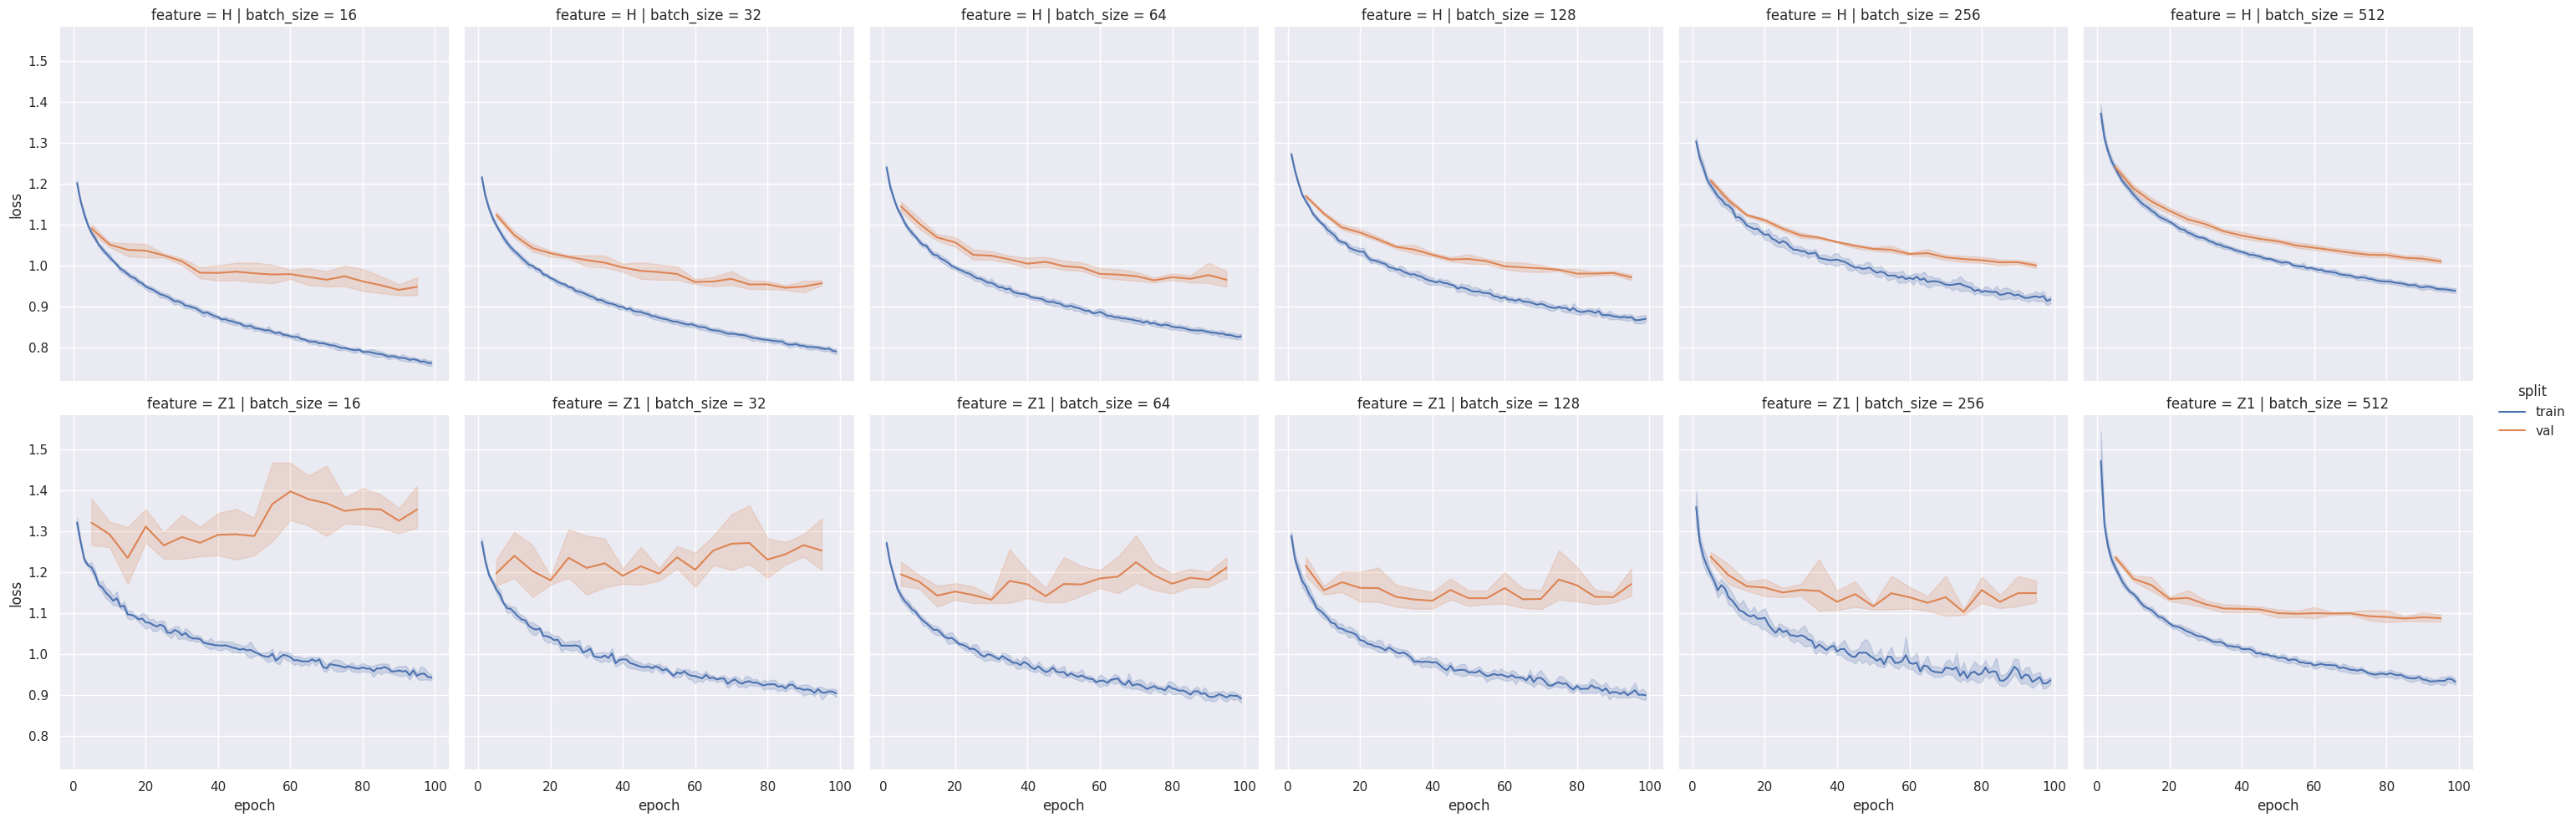

In [3]:
sns.relplot(
    data=df.loc[lambda x: (x.epoch > 0) & (x.split != "test")], 
    y="loss", x="epoch", kind="line", hue="split", col="batch_size", row="feature"
)

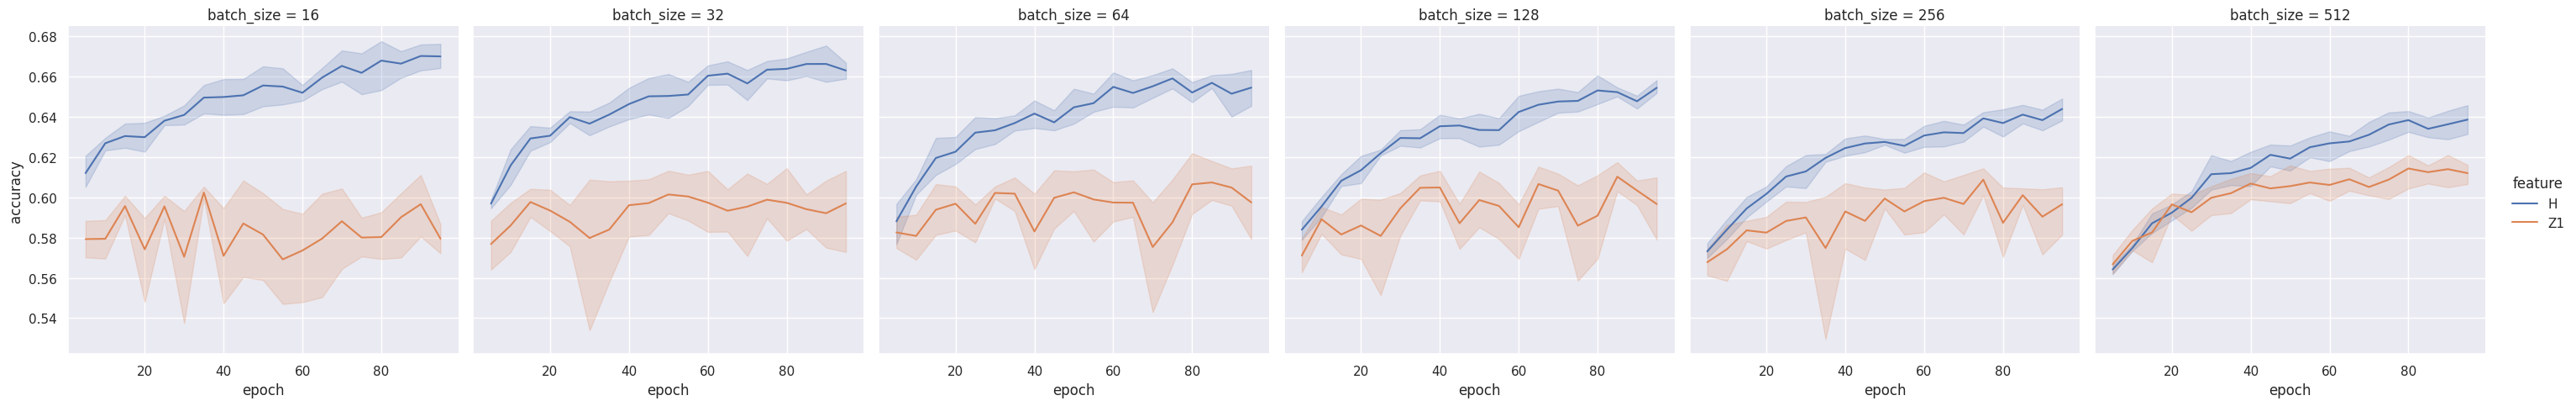

In [4]:
sns.relplot(
    data=df.loc[lambda x: (x.epoch > 0) & (x.split == "val")], 
    y="accuracy", x="epoch", kind="line", hue="feature", col="batch_size"
)

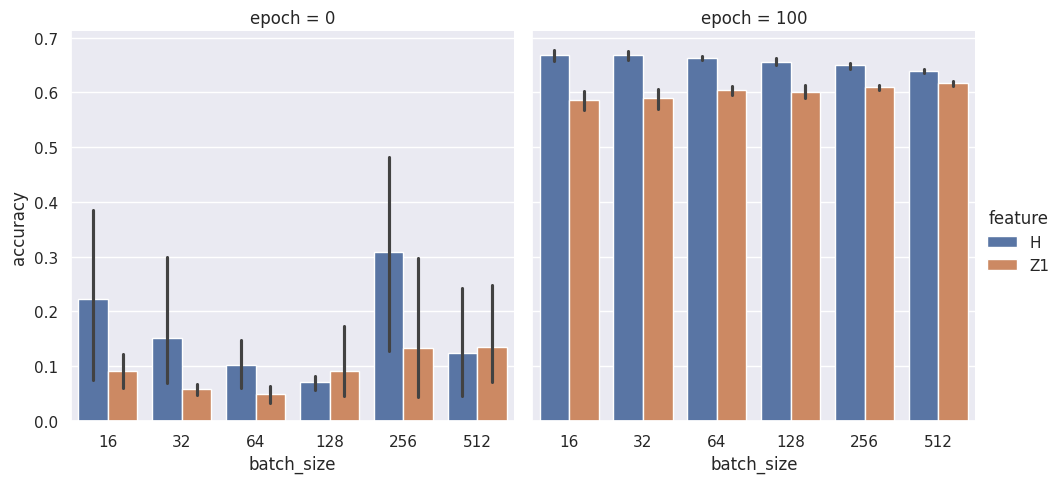

In [5]:
sns.catplot(
    data=df.loc[lambda x: (x.split == "test")], 
    y="accuracy", x="batch_size", hue="feature", kind="bar", col="epoch"
)

In [13]:
from pathlib import Path
def load_softmax(dset_path, repl):
    y_tilde_h = np.load(results_path / f"softmax_H_bs32_repl{repl}.npy") # Nxd
    y = np.load(f"simclr_features/y_test_subset{repl}.npy")
    return y_tilde_h, y

all_results = []
for i in range(5):
    y_tilde_h, y = load_softmax(Path("deepweeds"), i)
    sdf = (pd.DataFrame({"py": y_tilde_h[np.arange(len(y)), y], 
                         "y": y, 
                         "y_hat": y_tilde_h.argmax(axis=1)})
           .assign(py_hat=lambda x: y_tilde_h[np.arange(len(y)), x.y_hat])
           .assign(label=lambda x: [CLASS_NAMES[i] for i in x.y], repl=i,
                   label_hat=lambda x: [CLASS_NAMES[i] for i in x.y_hat]))
    # sdf = pd.DataFrame({"py": y_tilde_h.argmax(axis=1), "y": y}).assign(labels=lambda x: [CLASS_NAMES[i] for i in x.y], repl=i)
    all_results.append(sdf)

print(np.allclose(y_tilde_h.sum(axis=1), 1), y_tilde_h.shape, y.shape)
sdf = pd.concat(all_results).loc[lambda x: (x.repl == 0)]

True (3498, 9) (3498,)


0.6737952666096378


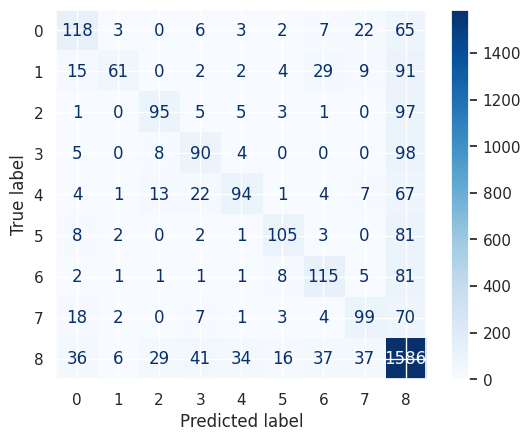

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

cm = confusion_matrix(sdf.label, sdf.label_hat, labels=CLASS_NAMES)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
score = accuracy_score(sdf.label, sdf.label_hat)
print(score)

# sns.relplot(sdf, x="py_hat", y="py", kind="scatter", aspect=1, height=4, col="label", hue="label_hat")

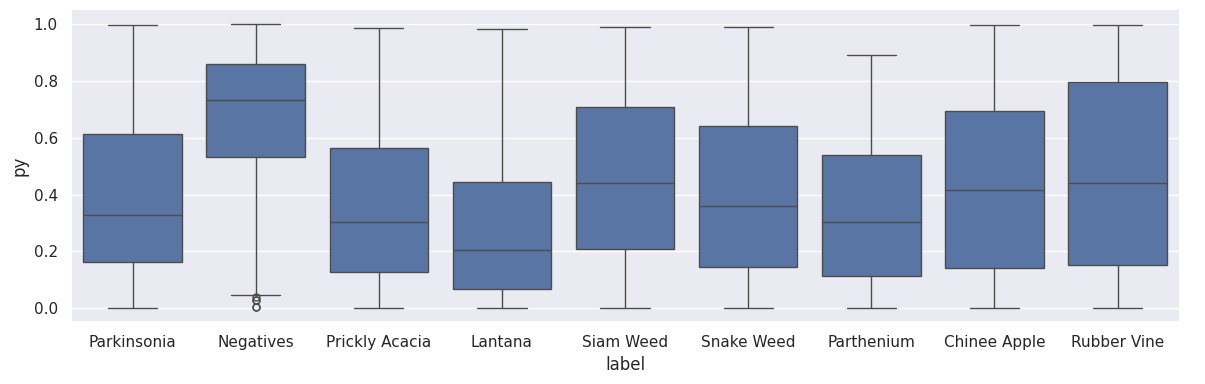

In [15]:
sns.catplot(sdf, x="label", y="py", kind="box", aspect=3, height=4)

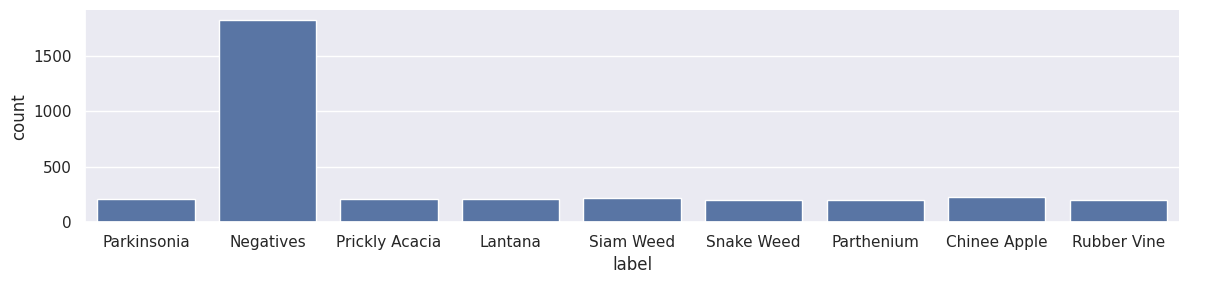

In [16]:
sns.catplot(sdf, x="label", kind="count", aspect=4, height=3)